In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


First, I'll unzip the `test.zip` and `train.zip` files from your Google Drive.

In [ ]:
import os

# Define the paths to the zipped files in Google Drive
test_zip_path = '/content/drive/MyDrive/fed/test.zip'
train_zip_path = '/content/drive/MyDrive/fed/train.zip'

# Define the target directory where files will be unzipped
unzip_dir = '/content/drive/MyDrive/fed/'

# Create the directory if it doesn't exist
os.makedirs(unzip_dir, exist_ok=True)

# Unzip the test file
print(f"Unzipping {test_zip_path} to {unzip_dir}...")
!unzip -o {test_zip_path} -d {unzip_dir}

# Unzip the train file
print(f"Unzipping {train_zip_path} to {unzip_dir}...")
!unzip -o {train_zip_path} -d {unzip_dir}

print("Unzipping complete.")

# List contents of the unzip directory to verify
print(f"Contents of {unzip_dir}:")
!ls {unzip_dir}

Streaming output truncated to the last 5000 lines.
  inflating: /content/drive/MyDrive/fed/train/sad/Training_65329617.jpg  
  inflating: /content/drive/MyDrive/fed/train/sad/Training_65338712.jpg  
  inflating: /content/drive/MyDrive/fed/train/sad/Training_65338797.jpg  
  inflating: /content/drive/MyDrive/fed/train/sad/Training_65387162.jpg  
  inflating: /content/drive/MyDrive/fed/train/sad/Training_65404494.jpg  
  inflating: /content/drive/MyDrive/fed/train/sad/Training_65426218.jpg  
  inflating: /content/drive/MyDrive/fed/train/sad/Training_65430136.jpg  
  inflating: /content/drive/MyDrive/fed/train/sad/Training_65437377.jpg  
  inflating: /content/drive/MyDrive/fed/train/sad/Training_6545735.jpg  
  inflating: /content/drive/MyDrive/fed/train/sad/Training_65463385.jpg  
  inflating: /content/drive/MyDrive/fed/train/sad/Training_65473985.jpg  
  inflating: /content/drive/MyDrive/fed/train/sad/Training_65502829.jpg  
  inflating: /content/drive/MyDrive/fed/train/sad/Training_655

In [ ]:
# Install TensorFlow
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 757.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 92.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 104.9 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


Based on the unzipped contents, it appears we are dealing with image data for a classification task. I will now load these images into TensorFlow datasets, apply basic preprocessing like resizing and rescaling, and visualize some samples.

In [ ]:
import tensorflow as tf

# Define the paths to the train and test directories
train_dir = '/content/drive/MyDrive/fed/train'
test_dir = '/content/drive/MyDrive/fed/test'

# Define image parameters
IMG_HEIGHT = 48 # Common size for emotion recognition datasets like FER2013
IMG_WIDTH = 48
BATCH_SIZE = 32

# Load the training dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

# Load the testing dataset
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False # Typically no need to shuffle test data
)

print(f"Number of training batches: {len(train_ds)}")
print(f"Number of testing batches: {len(test_ds)}")

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


Found 28709 files belonging to 7 classes.
Found 7178 files belonging to 7 classes.
Number of training batches: 898
Number of testing batches: 225


The `image_dataset_from_directory` function automatically infers class labels from the subdirectory names. Let's get the class names and apply a rescaling function to normalize pixel values.

In [ ]:
class_names = train_ds.class_names
print(f"Class names: {class_names}")

# Function to normalize pixel values from [0, 255] to [0, 1]
def normalize(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# Apply normalization to both datasets
train_ds = train_ds.map(normalize)
test_ds = test_ds.map(normalize)

# Configure datasets for performance
train_ds = train_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

print("Datasets preprocessed and configured for performance.")

Class names: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Datasets preprocessed and configured for performance.


Let's visualize a few images from the training dataset to ensure everything is loaded correctly.

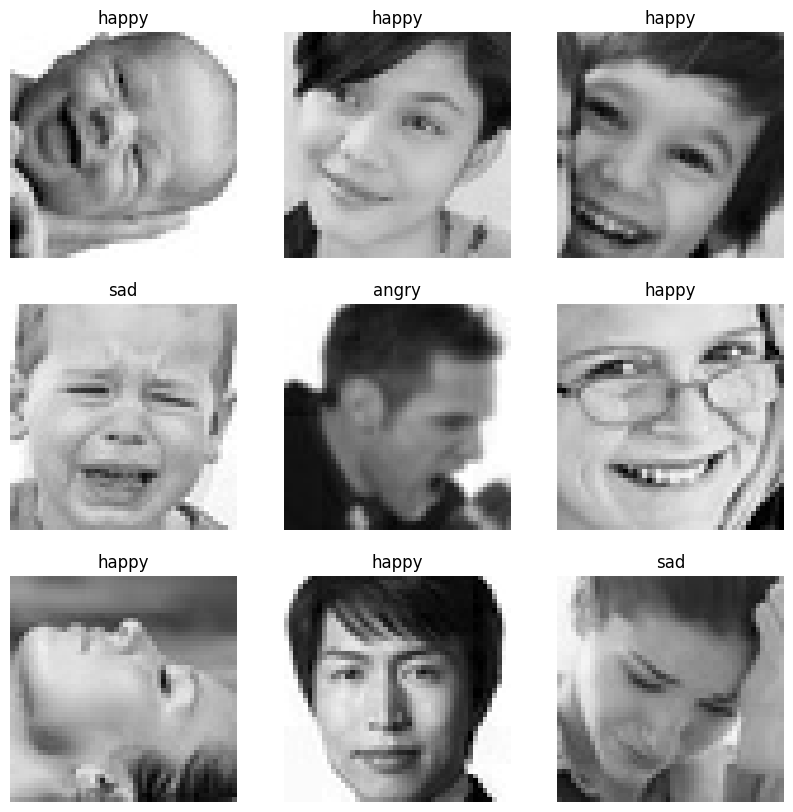

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

Now, let's define and compile a Convolutional Neural Network (CNN) model.

In [ ]:
from tensorflow.keras import layers, models

# Define the CNN model architecture
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(class_names), activation='softmax') # Output layer with number of classes and softmax for probabilities
])

# Compile the model
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,423 (1.36 MB)

 Trainable params: 356,423 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

Next, I will train the CNN model using the preprocessed training and validation datasets.

In [ ]:
EPOCHS = 10 # You can adjust the number of epochs

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS
)

Epoch 1/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 67s 74ms/step - accuracy: 0.3507 - loss: 1.6410 - val_accuracy: 0.4411 - val_loss: 1.4426
Epoch 2/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 38s 43ms/step - accuracy: 0.4799 - loss: 1.3653 - val_accuracy: 0.4999 - val_loss: 1.3016
Epoch 3/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 39s 43ms/step - accuracy: 0.5323 - loss: 1.2272 - val_accuracy: 0.5227 - val_loss: 1.2548
Epoch 4/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 38s 43ms/step - accuracy: 0.5708 - loss: 1.1333 - val_accuracy: 0.5248 - val_loss: 1.2478
Epoch 5/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 38s 43ms/step - accuracy: 0.6052 - loss: 1.0512 - val_accuracy: 0.5380 - val_loss: 1.2578
Epoch 6/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 37s 41ms/step - accuracy: 0.6351 - loss: 0.9727 - val_accuracy: 0.5248 - val_loss: 1.3203
Epoch 7/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 37s 41ms/step - accuracy: 0.6671 - loss: 0.8992 - val_accuracy: 0.5096 - val_loss: 1.3962
Epoch 8/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 37s 41ms/step - accuracy: 0.6925 - loss: 0.8272 - 

After training, let's evaluate the model's performance on the test dataset and visualize the training history.

225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5265 - loss: 1.5949
Test Loss: 1.5949
Test Accuracy: 0.5265


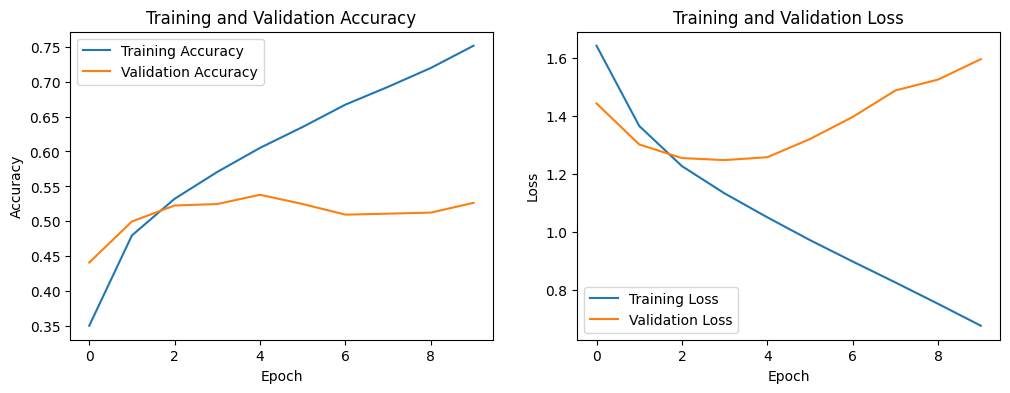

In [ ]:
import matplotlib.pyplot as plt

# Evaluate the model on the test dataset
loss, accuracy = model.evaluate(test_ds)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.show()

Finally, let's generate and display the confusion matrix to see how well the model classifies each emotion.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━

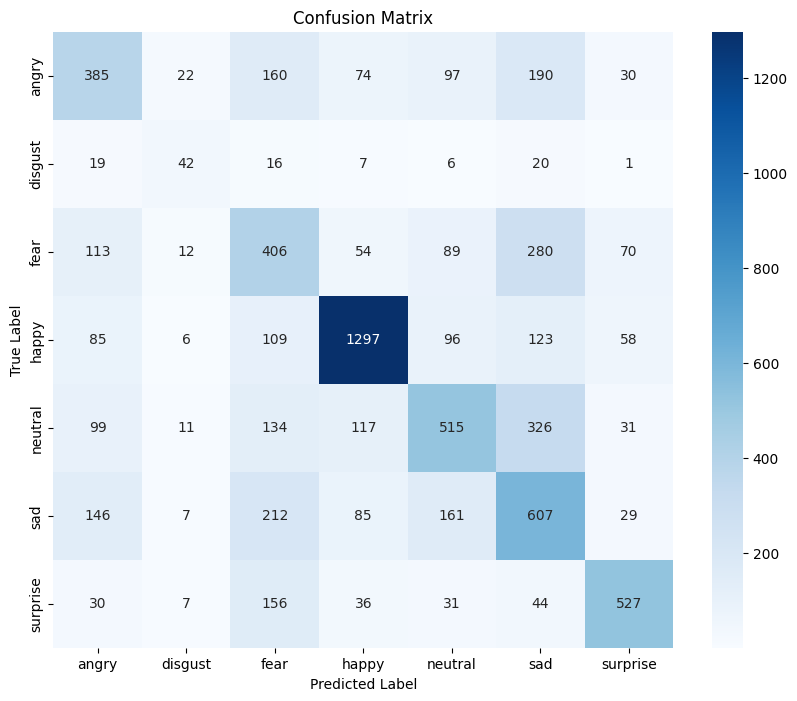

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Get true labels and predictions for the test set
y_true = []
y_pred = []

for images, labels in test_ds:
    y_true.extend(labels.numpy())
    predictions = model.predict(images)
    y_pred.extend(np.argmax(predictions, axis=1))

# Calculate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()